In [1]:
# Import Libraries and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset from previous lab
df = pd.read_csv("cleaned_dataset.csv")
df=df.drop(df.columns[0],axis=1)
print("Shape:", df.shape)

df
# print(df.head())

Shape: (891, 13)


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Gender_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0.271174,1,0,A/5 21171,0.014151,T,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.472229,1,0,PC 17599,0.139136,C85,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0.321438,0,0,STON/O2. 3101282,0.015469,T,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.434531,1,0,113803,0.103644,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0.434531,0,0,373450,0.015713,T,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0.334004,0,0,211536,0.025374,T,True,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",0.233476,0,0,112053,0.058556,B42,False,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0.367921,1,2,W./C. 6607,0.045771,T,False,False,True
889,890,1,1,"Behr, Mr. Karl Howell",0.321438,0,0,111369,0.058556,C148,True,False,False


In [2]:
# Basic Statistical Summary

# Descriptive statistics for numerical features
print(df.describe())

# Information about dataset
print(df.info())

# Unique values per column
print(df.nunique())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642    0.367921    0.523008   
std     257.353842    0.486592    0.836071    0.163383    1.102743   
min       1.000000    0.000000    1.000000    0.000000    0.000000   
25%     223.500000    0.000000    2.000000    0.271174    0.000000   
50%     446.000000    0.000000    3.000000    0.367921    0.000000   
75%     668.500000    1.000000    3.000000    0.434531    1.000000   
max     891.000000    1.000000    3.000000    1.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594    0.062858  
std      0.806057    0.096995  
min      0.000000    0.000000  
25%      0.000000    0.015440  
50%      0.000000    0.028213  
75%      0.000000    0.060508  
max      6.000000    1.000000  
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 

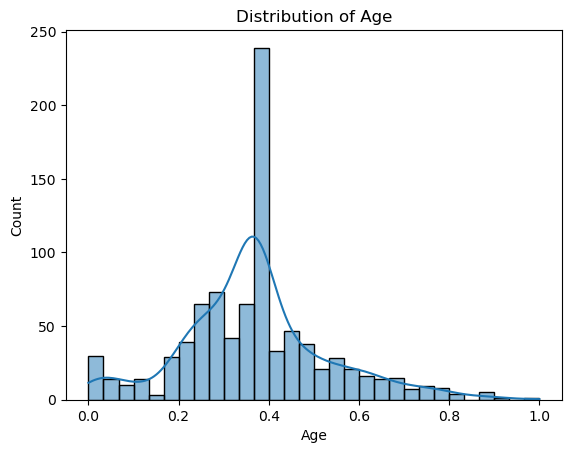

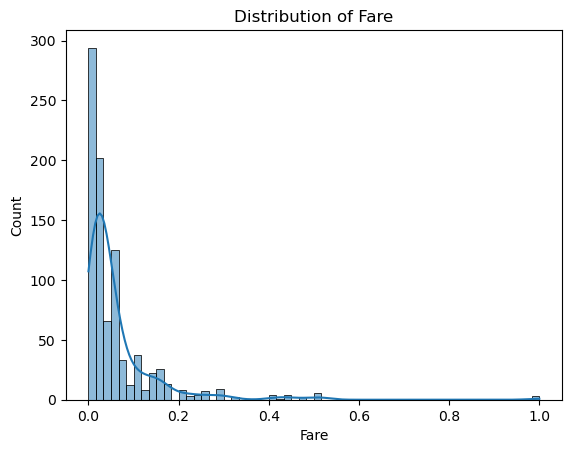

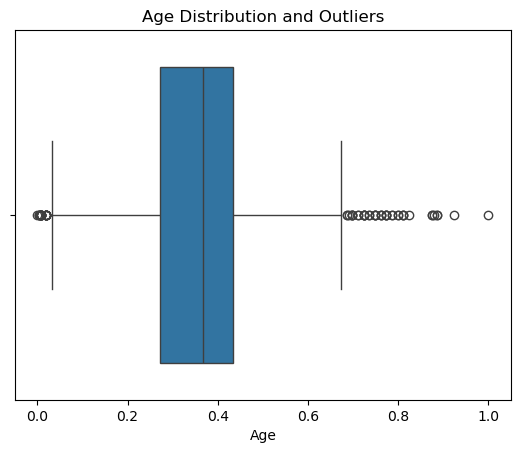

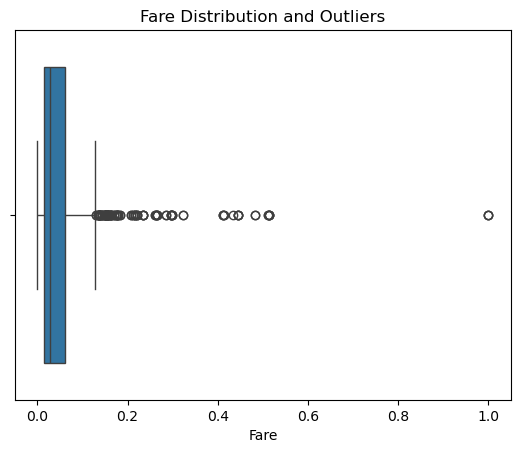

In [3]:
# Visualize Distributions

# Histogram and density plot
sns.histplot(df['Age'], kde=True)
plt.title("Distribution of Age")
plt.show()

sns.histplot(df['Fare'], kde=True)
plt.title("Distribution of Fare")
plt.show()

# Boxplot for salary to detect outliers
sns.boxplot(x=df['Age'])
plt.title("Age Distribution and Outliers")
plt.show()

sns.boxplot(x=df['Fare'])
plt.title("Fare Distribution and Outliers")
plt.show()

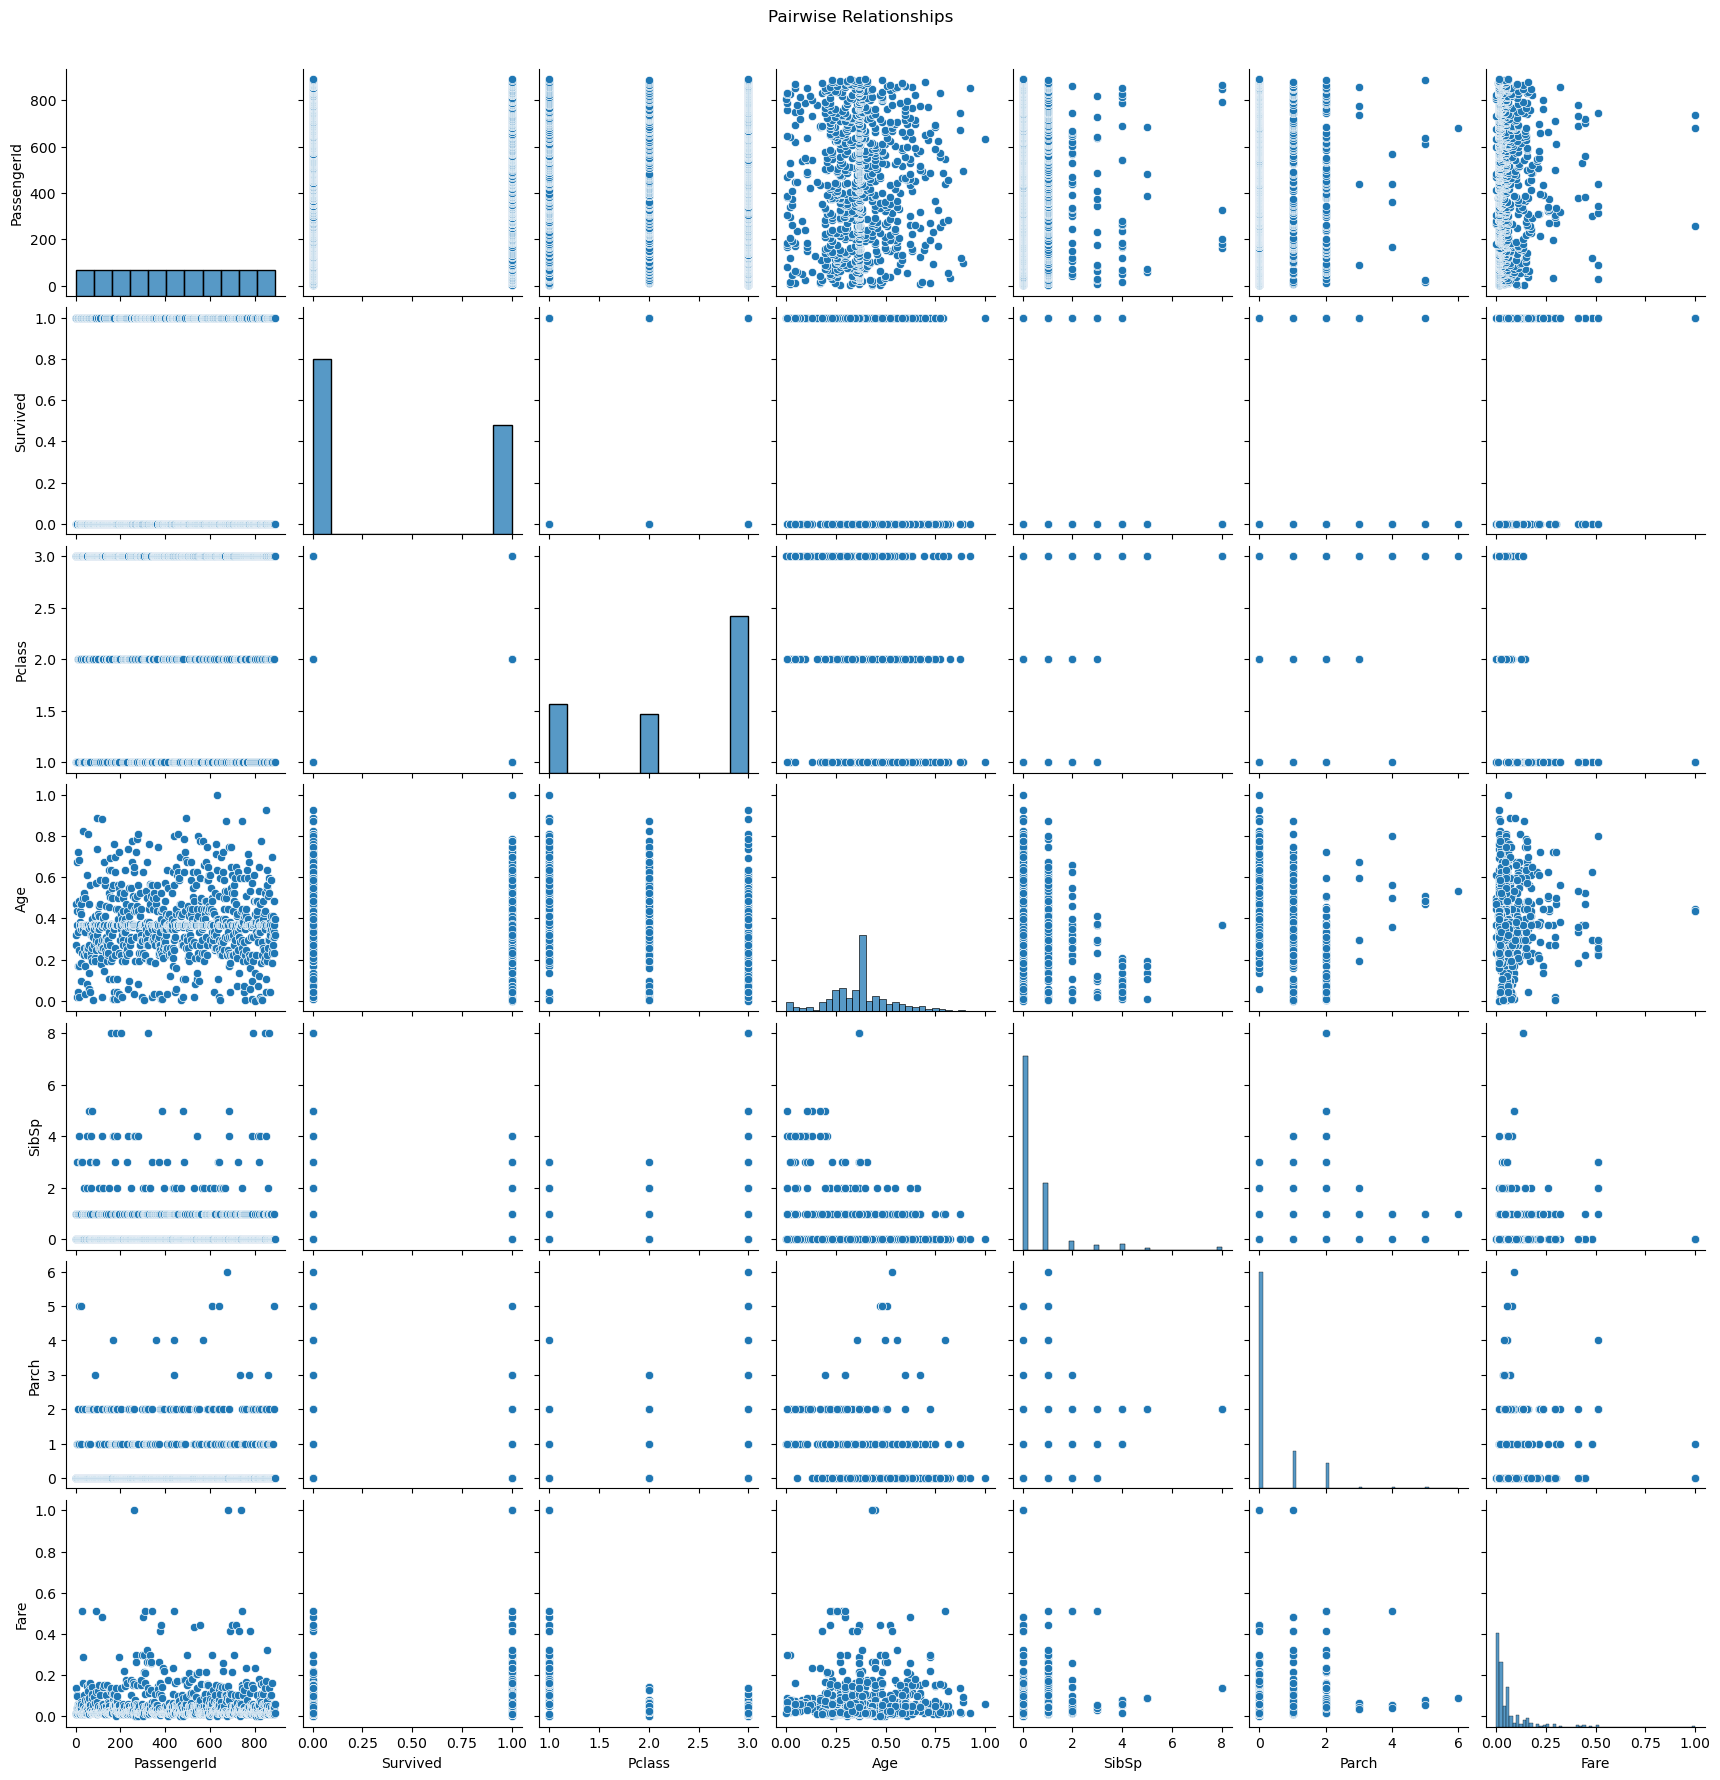

In [4]:
# Relationship Between Variables

# Pairwise relationships among numeric features
sns.pairplot(df.select_dtypes('number'))
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()

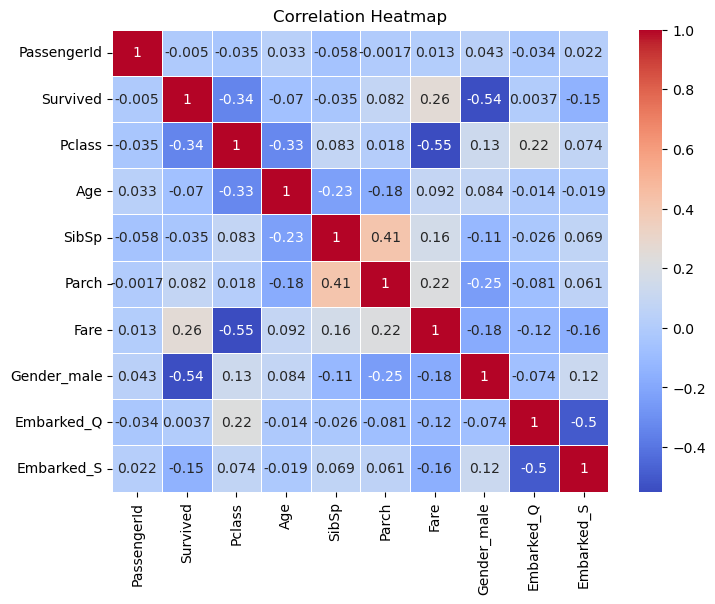

In [5]:
# Correlation Heatmap

corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

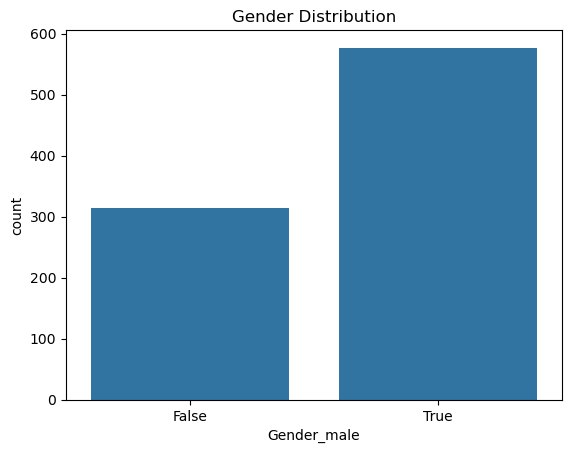

Embarked_S,False,True
Gender_male,,
False,34.713376,65.286624
True,23.570191,76.429809


In [6]:
# Categorical Variable Analysis

# Count plot for categorical features
sns.countplot(x='Gender_male', data=df)
plt.title("Gender Distribution")
plt.show()

# Cross-tabulation: Gender vs Embarked
pd.crosstab(df['Gender_male'], df['Embarked_Q'], normalize='index') * 100
pd.crosstab(df['Gender_male'], df['Embarked_S'], normalize='index') * 100

In [7]:
# Outlier Detection (Z-Score Method)

from scipy import stats

z = np.abs(stats.zscore(df.select_dtypes('number')))
outliers = (z > 3).sum(axis=0)
print("Outliers per column:\n", outliers)

Outliers per column:
 [ 0  0  0  7 30 15 20]
